Cell 1 — setup

In [32]:
from pathlib import Path
import pandas as pd

# Anchor to project root regardless of where the kernel starts
ROOT = Path(r"C:\Users\sclab\Desktop\A hackaton")
RAW  = ROOT / "data" / "raw"

print("RAW exists:", RAW.exists())
print("CSVs:", [f.name for f in RAW.glob("*.csv")])

RAW exists: True
CSVs: ['crop_yield_leaderboard_test.csv', 'crop_yield_train.csv', 'market_prices.csv', 'regional_weather.csv', 'submission_template.csv']


In [33]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\sclab\Desktop\A hackaton")
raw       = PROJECT_ROOT / "data" / "raw"
processed = PROJECT_ROOT / "data" / "processed"
figdir    = PROJECT_ROOT / "figures"
figdir.mkdir(exist_ok=True)

print("raw       exists:", raw.exists())
print("processed exists:", processed.exists())

train    = pd.read_csv(processed / "master_train.csv")
test     = pd.read_csv(processed / "master_test.csv")
weather  = pd.read_csv(raw / "regional_weather.csv")
prices   = pd.read_csv(raw / "market_prices.csv")
template = pd.read_csv(raw / "submission_template.csv")

print("train:", train.shape, "| test:", test.shape)
print("weather:", weather.shape, "| prices:", prices.shape, "| template:", template.shape)

raw       exists: True
processed exists: True
train: (15090, 25) | test: (3750, 24)
weather: (232, 6) | prices: (100, 4) | template: (3750, 2)


Cell 2 — fig01 missingness

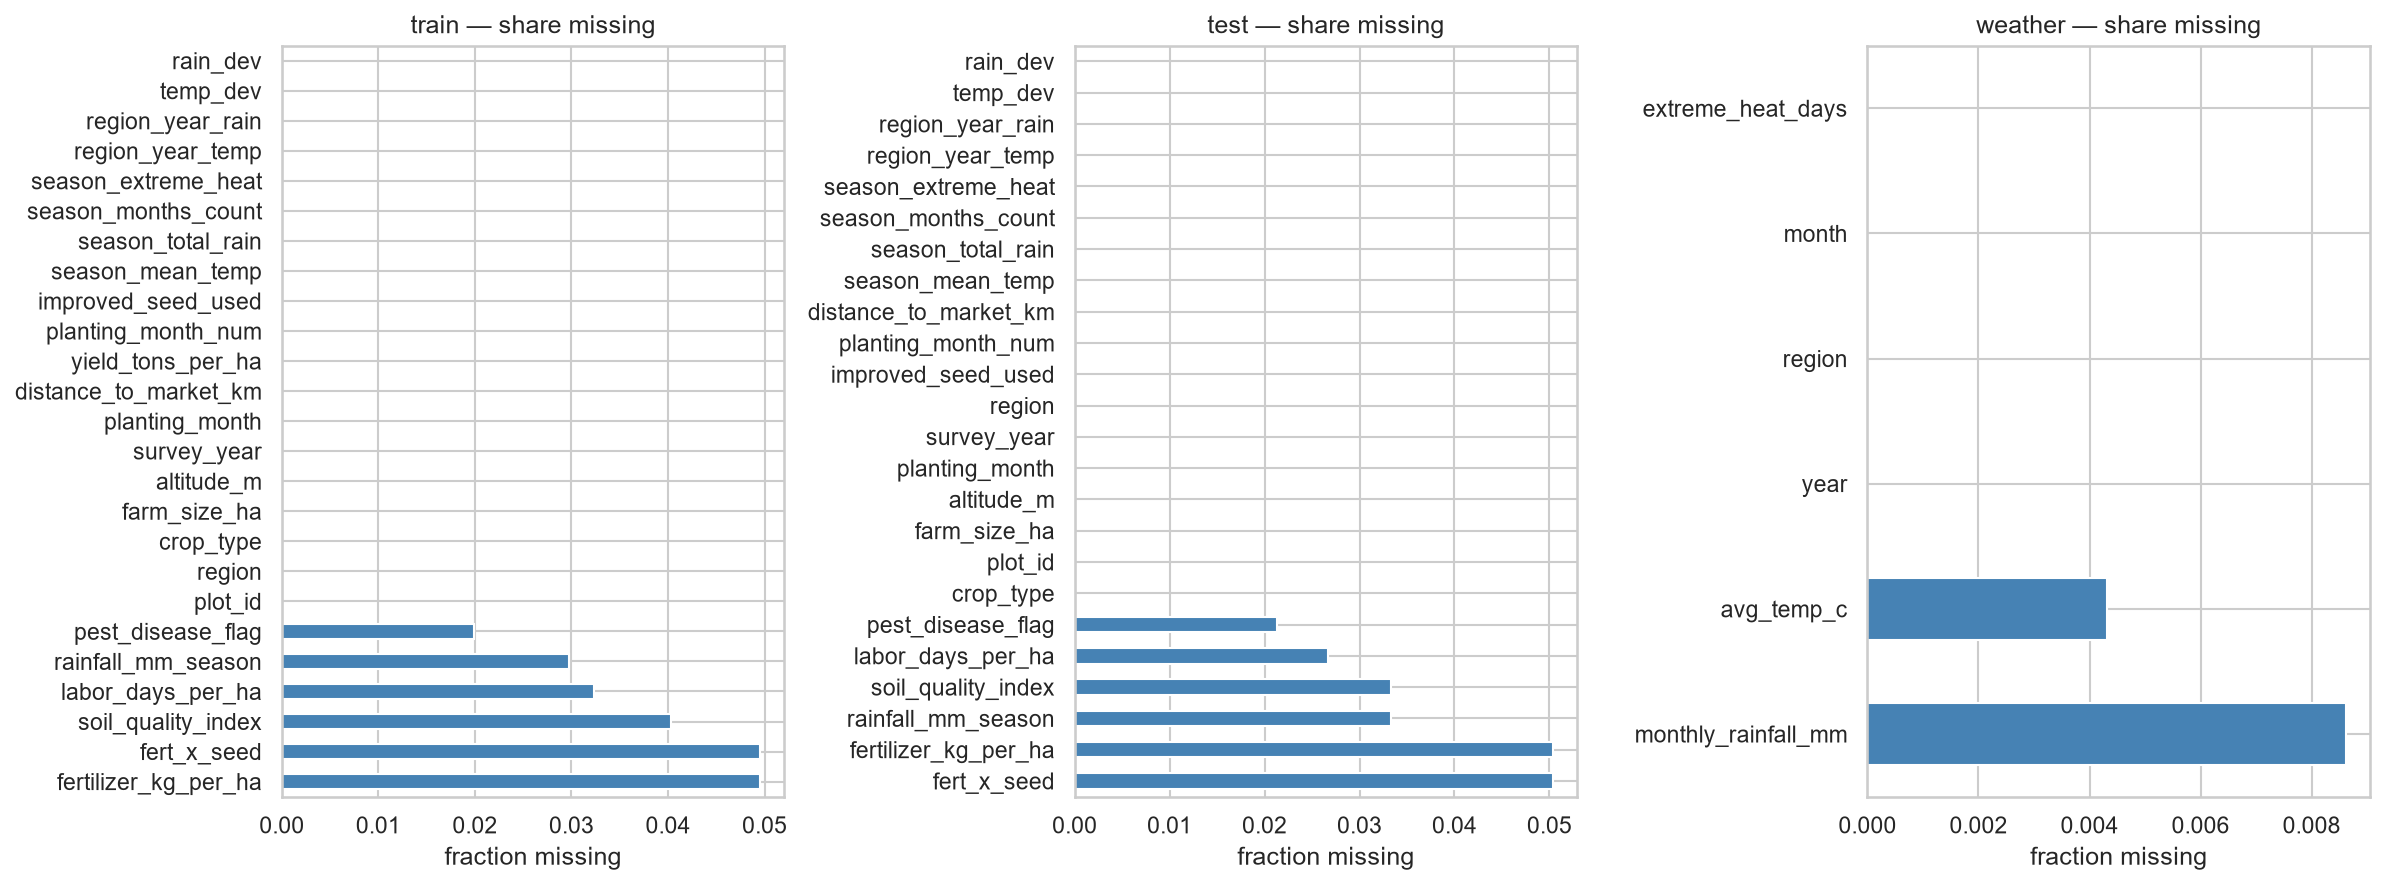

In [34]:
import missingno as msno
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (name, df) in zip(axes, [("train", train), ("test", test), ("weather", weather)]):
    share = df.isna().mean().sort_values(ascending=False)
    share.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{name} — share missing"); ax.set_xlabel("fraction missing")
plt.tight_layout(); plt.savefig(figdir/"fig01_missingness.png", bbox_inches="tight"); plt.show()

Cell 3 — fig02 before/after cleaning

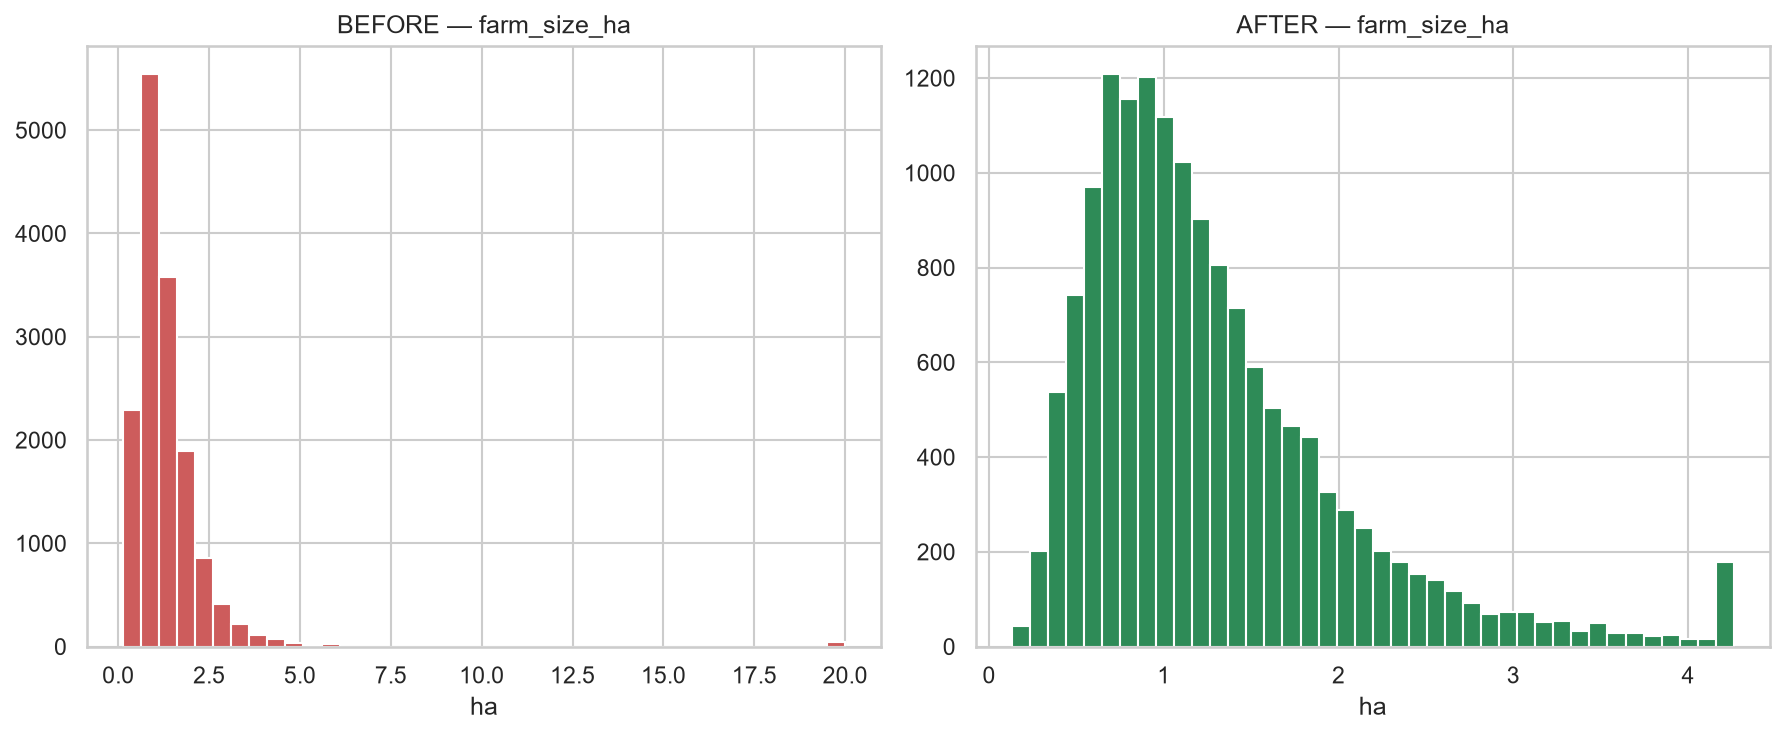

In [35]:
raw_train = pd.read_csv(raw / "crop_yield_train.csv")
raw_train.replace([-999,-999.0], np.nan, inplace=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(raw_train["farm_size_ha"].dropna().clip(upper=20), bins=40, color="indianred")
axes[0].set_title("BEFORE — farm_size_ha"); axes[0].set_xlabel("ha")
axes[1].hist(train["farm_size_ha"].dropna(), bins=40, color="seagreen")
axes[1].set_title("AFTER — farm_size_ha"); axes[1].set_xlabel("ha")
plt.tight_layout(); plt.savefig(figdir/"fig02_before_after_cleaning.png", bbox_inches="tight"); plt.show()

Cell 4 — fig03 yield distribution

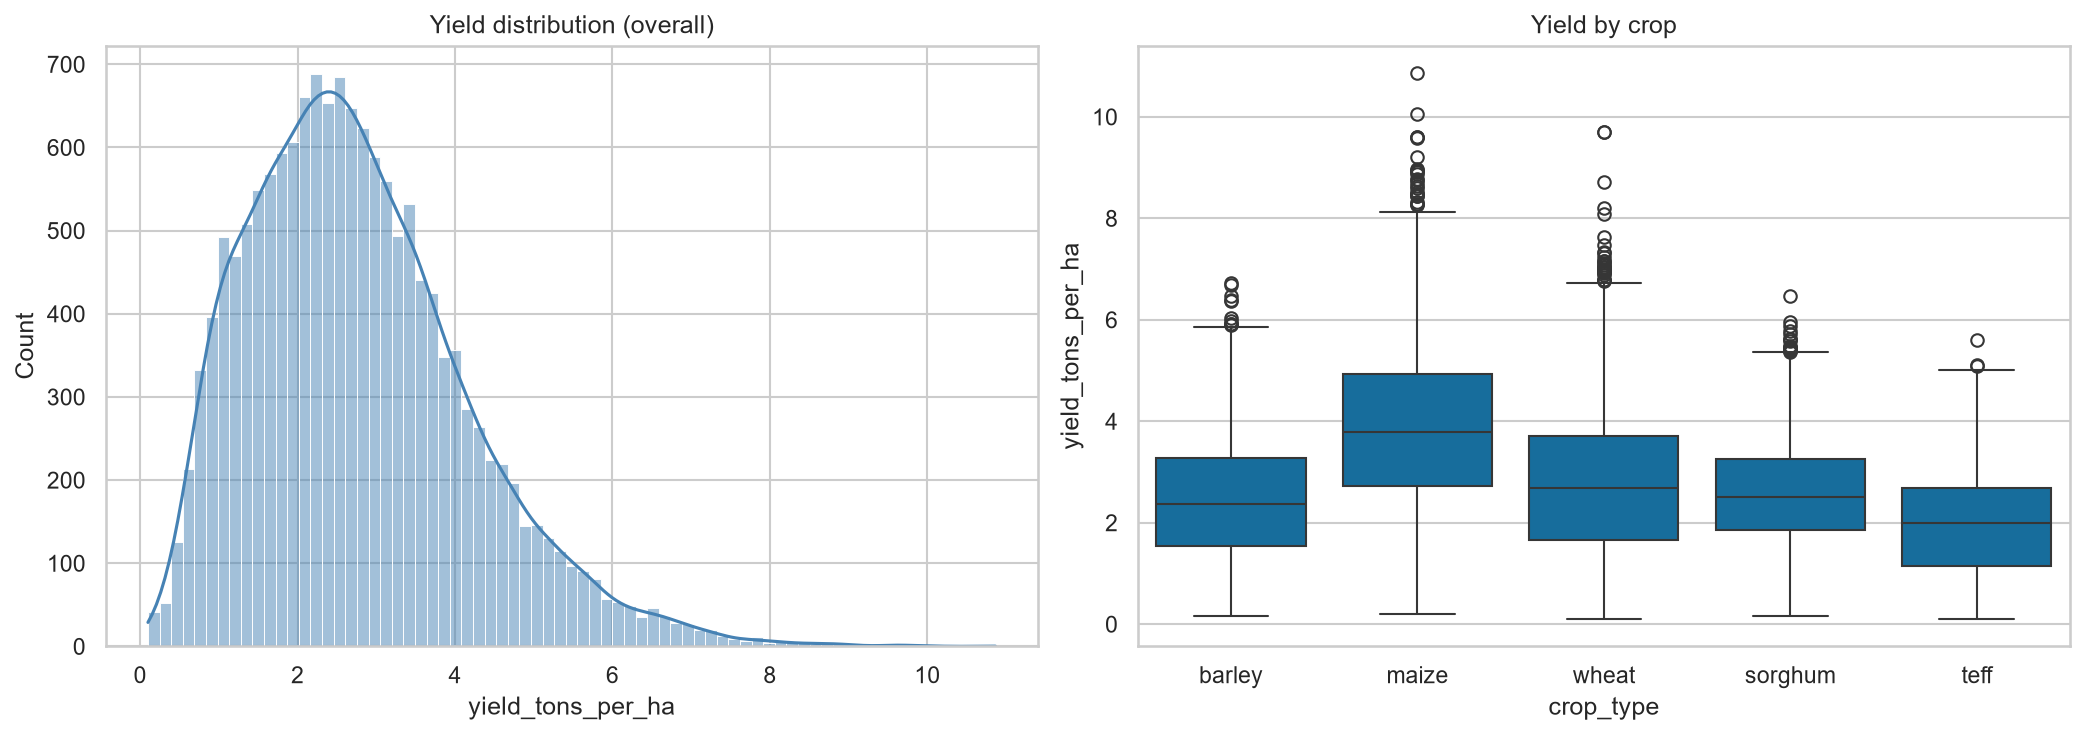

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train["yield_tons_per_ha"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Yield distribution (overall)")
sns.boxplot(data=train, x="crop_type", y="yield_tons_per_ha", ax=axes[1])
axes[1].set_title("Yield by crop")
plt.tight_layout(); plt.savefig(figdir/"fig03_yield_distribution.png", bbox_inches="tight"); plt.show()

Cell 5 — fig04 region × crop heatmap

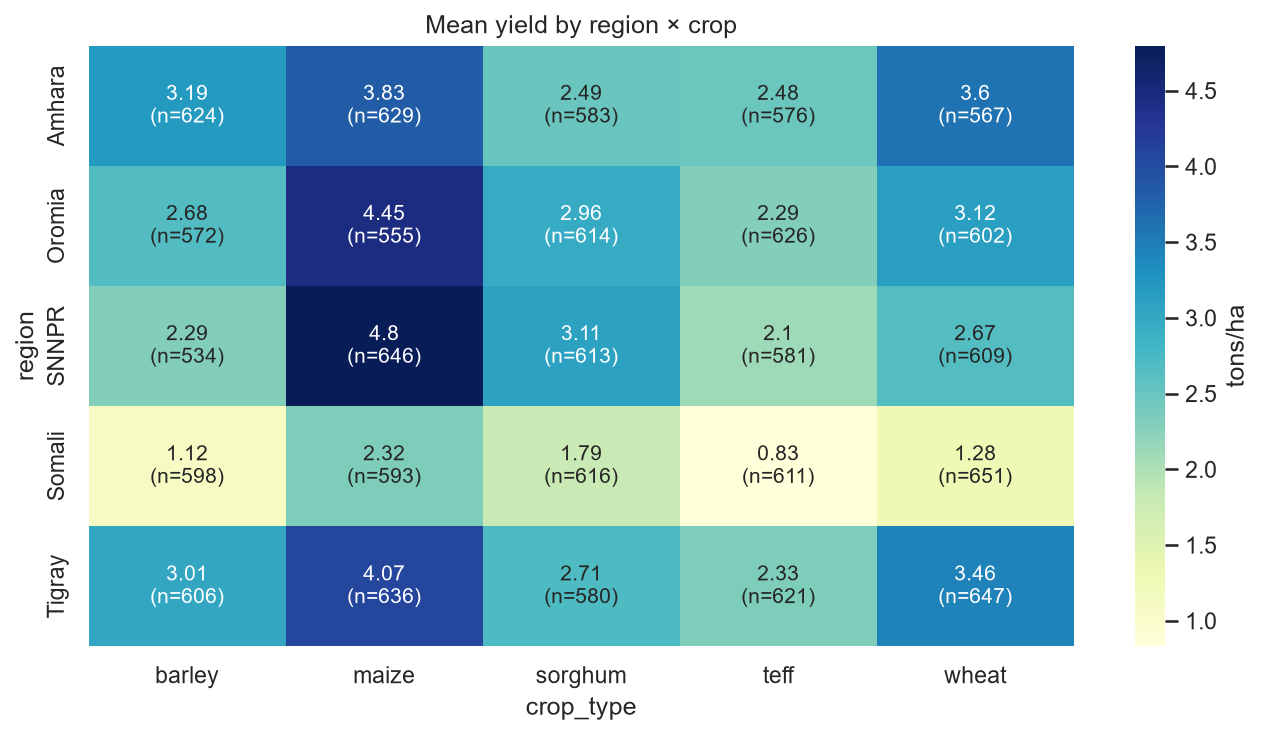

In [37]:
piv = train.pivot_table(index="region", columns="crop_type",
                        values="yield_tons_per_ha", aggfunc="mean")
cnt = train.pivot_table(index="region", columns="crop_type",
                        values="yield_tons_per_ha", aggfunc="count").fillna(0).astype(int)
labels = piv.round(2).astype(str) + "\n(n=" + cnt.astype(str) + ")"
plt.figure(figsize=(9, 5))
sns.heatmap(piv, annot=labels, fmt="", cmap="YlGnBu", cbar_kws={"label":"tons/ha"})
plt.title("Mean yield by region × crop")
plt.tight_layout(); plt.savefig(figdir/"fig04_region_crop_heatmap.png", bbox_inches="tight"); plt.show()

Cell 6 — fig05 correlation heatmap

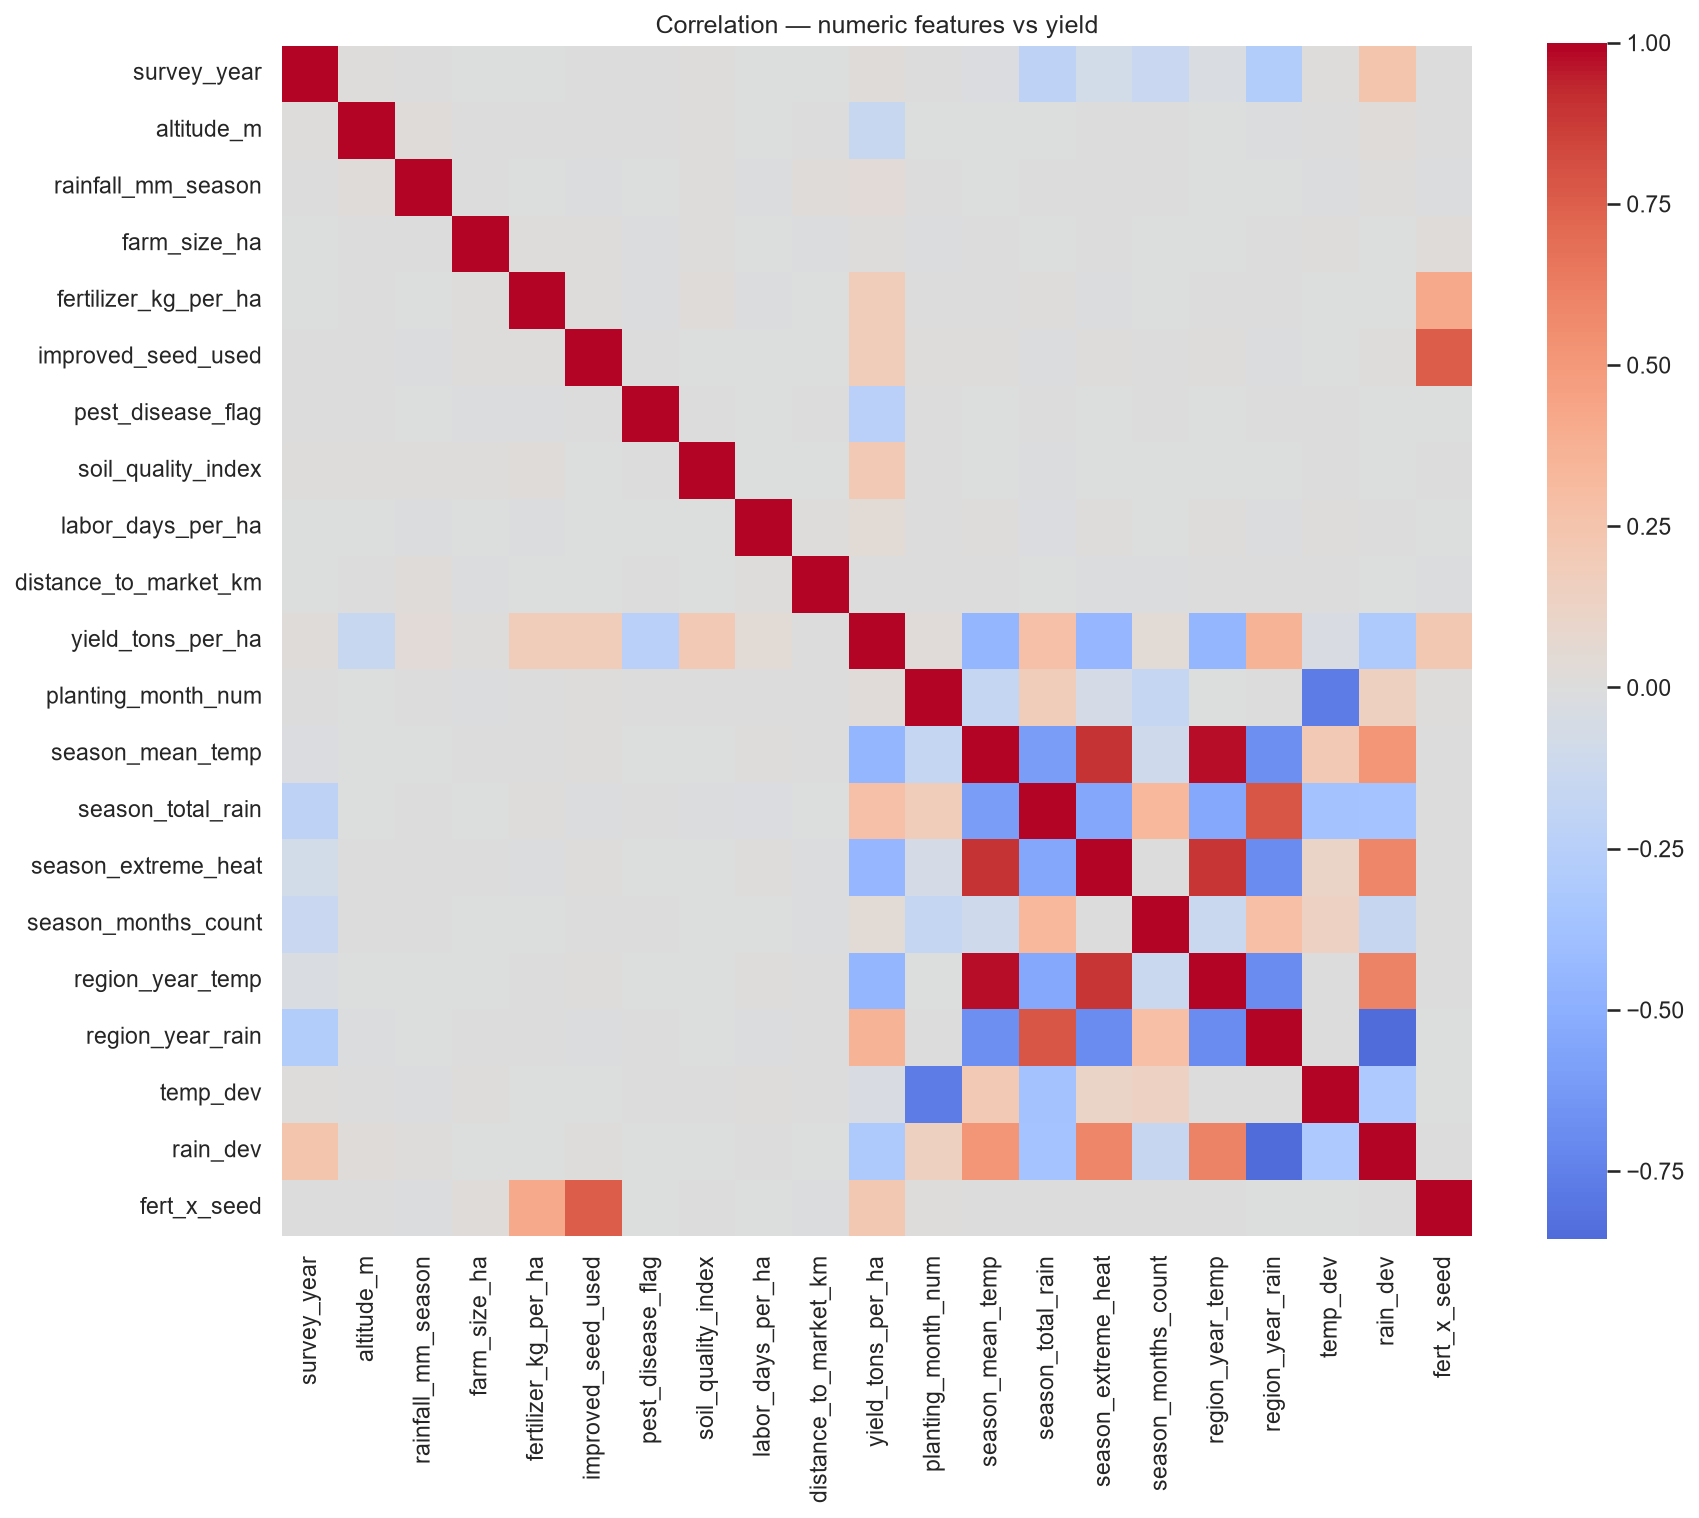

In [38]:
num = train.select_dtypes(include=np.number)
plt.figure(figsize=(12, 10))
sns.heatmap(num.corr(), cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation — numeric features vs yield")
plt.tight_layout(); plt.savefig(figdir/"fig05_correlation_heatmap.png", bbox_inches="tight"); plt.show()

Cell 7 — fig06 climate by region

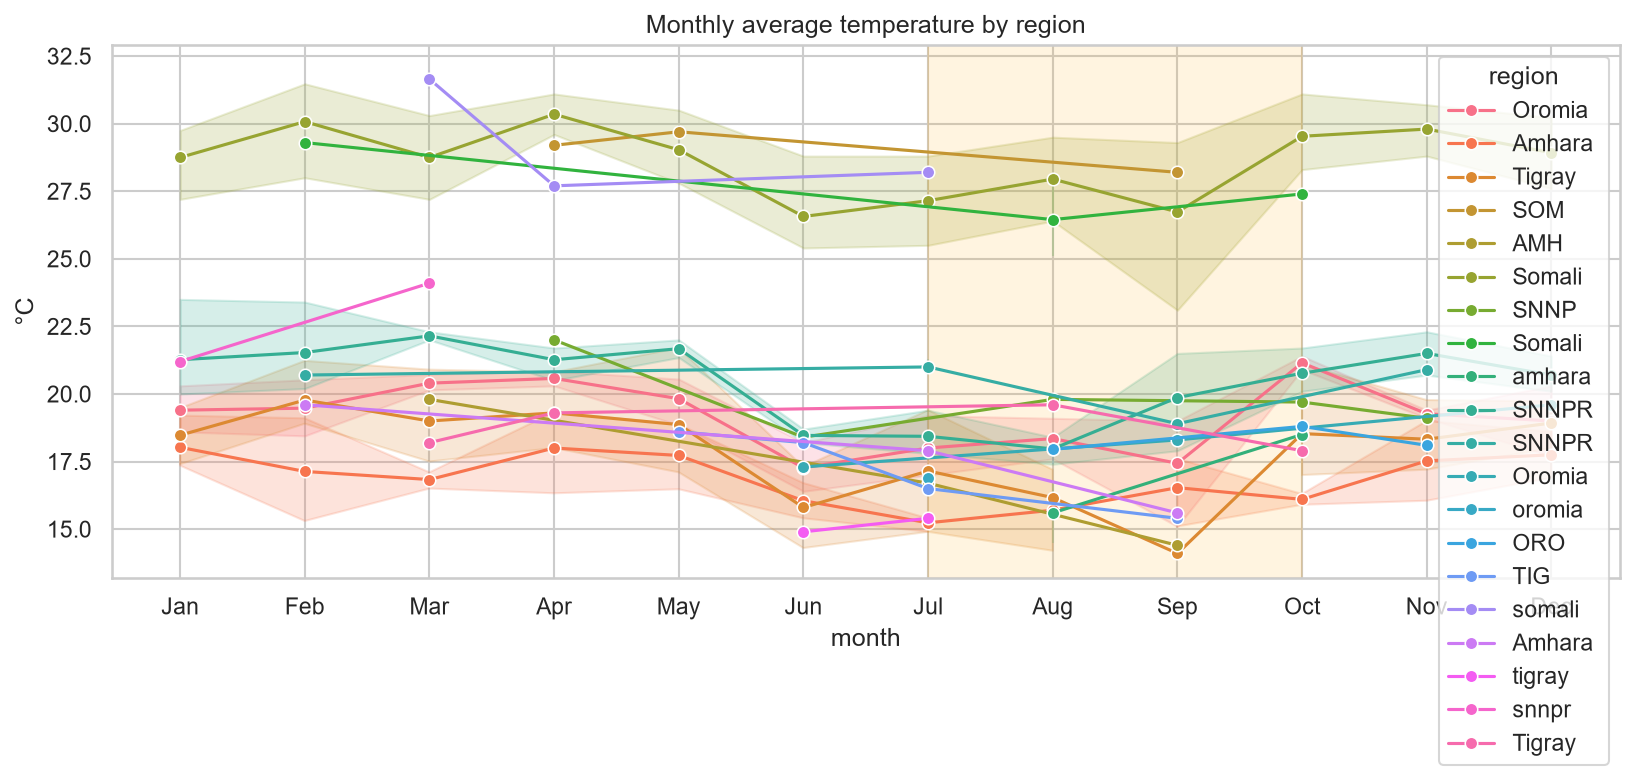

In [39]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
weather["month"] = pd.Categorical(weather["month"], categories=month_order, ordered=True)
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=weather, x="month", y="avg_temp_c", hue="region", ax=ax, marker="o")
ax.axvspan("Jul","Oct", alpha=0.12, color="orange", label="typical kiremt season")
ax.set_title("Monthly average temperature by region"); ax.set_ylabel("°C")
plt.tight_layout(); plt.savefig(figdir/"fig06_climate_by_region.png", bbox_inches="tight"); plt.show()

Cell 8 — fig07 yield vs season temp

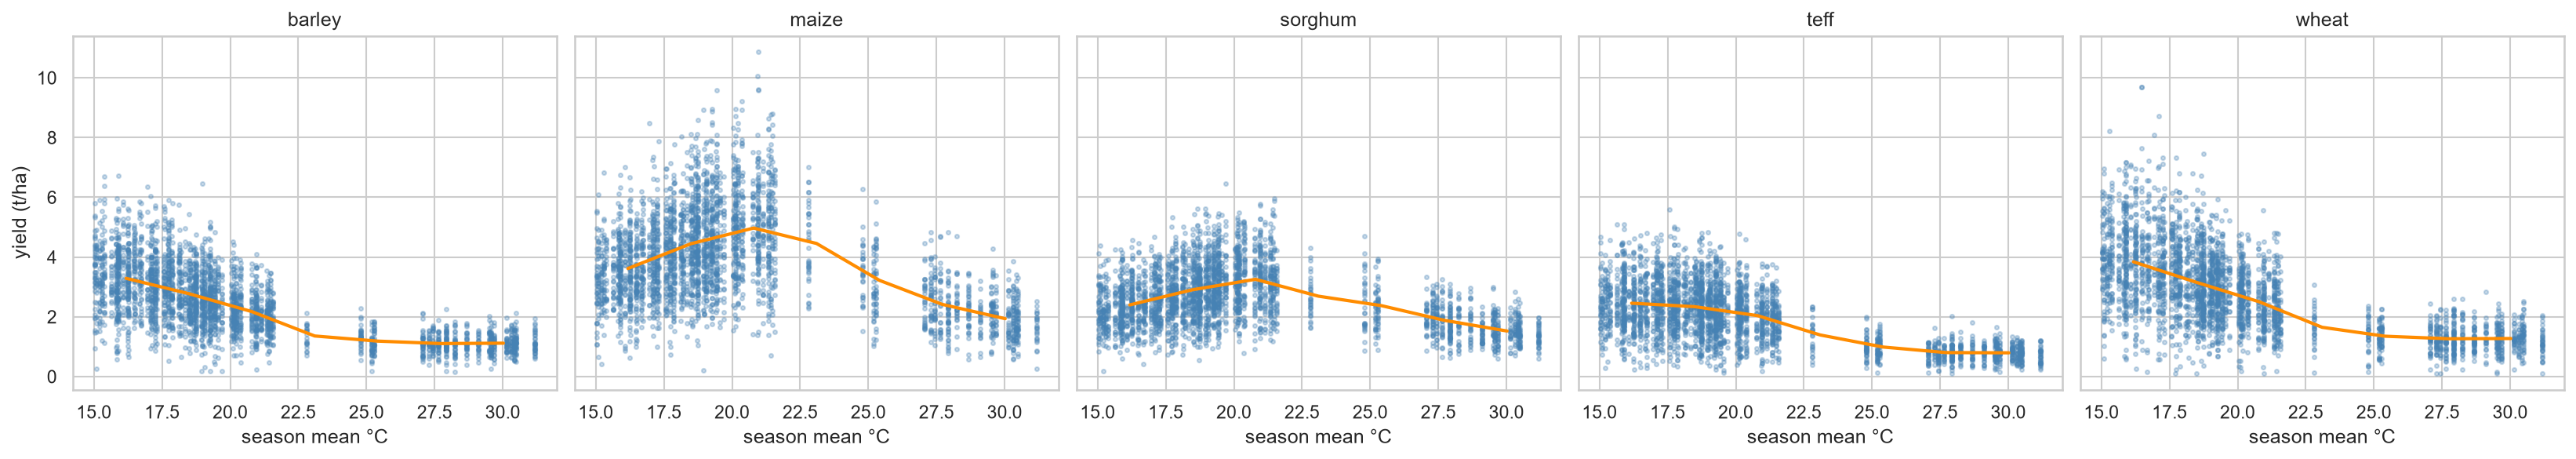

In [40]:
crops = sorted(train["crop_type"].unique())
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for ax, c in zip(axes, crops):
    sub = train[train["crop_type"]==c]
    ax.scatter(sub["season_mean_temp"], sub["yield_tons_per_ha"], s=6, alpha=0.3, color="steelblue")
    bins = np.linspace(sub["season_mean_temp"].min(), sub["season_mean_temp"].max(), 8)
    sub["bin"] = pd.cut(sub["season_mean_temp"], bins)
    m = sub.groupby("bin")["yield_tons_per_ha"].mean()
    x = [b.mid for b in m.index]
    ax.plot(x, m.values, color="darkorange", linewidth=2, label="binned mean")
    ax.set_title(c); ax.set_xlabel("season mean °C")
axes[0].set_ylabel("yield (t/ha)")
plt.tight_layout(); plt.savefig(figdir/"fig07_yield_vs_season_temp.png", bbox_inches="tight"); plt.show()

Cell 9 — fig08 price trends

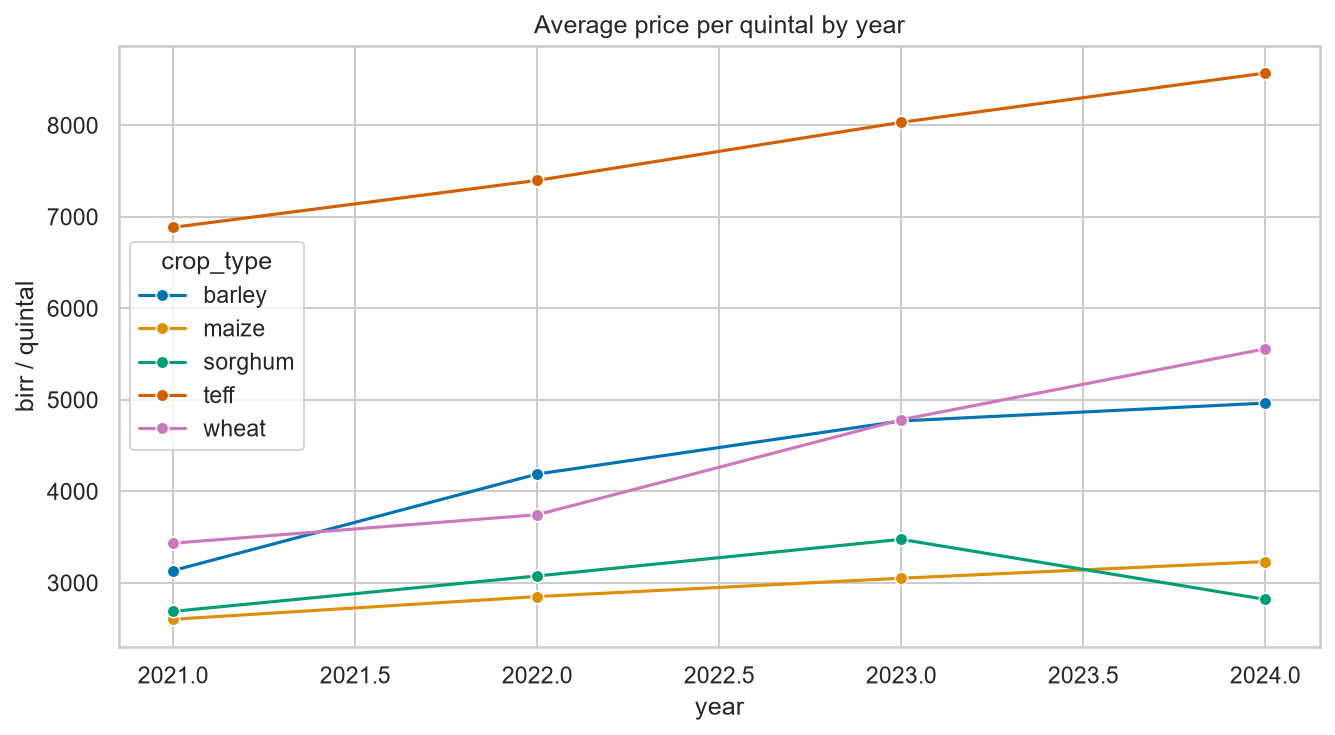

In [41]:
prices["crop_type"] = prices["crop_type"].str.strip().str.lower()
prices["crop_type"] = prices["crop_type"].replace({"tef":"teff"})
avg = prices.groupby(["crop_type","year"])["price_birr_per_quintal"].mean().reset_index()
plt.figure(figsize=(9, 5))
sns.lineplot(data=avg, x="year", y="price_birr_per_quintal", hue="crop_type", marker="o")
plt.title("Average price per quintal by year"); plt.ylabel("birr / quintal")
plt.tight_layout(); plt.savefig(figdir/"fig08_price_trends.png", bbox_inches="tight"); plt.show()

Cell 10 — fig09 revenue by crop × region

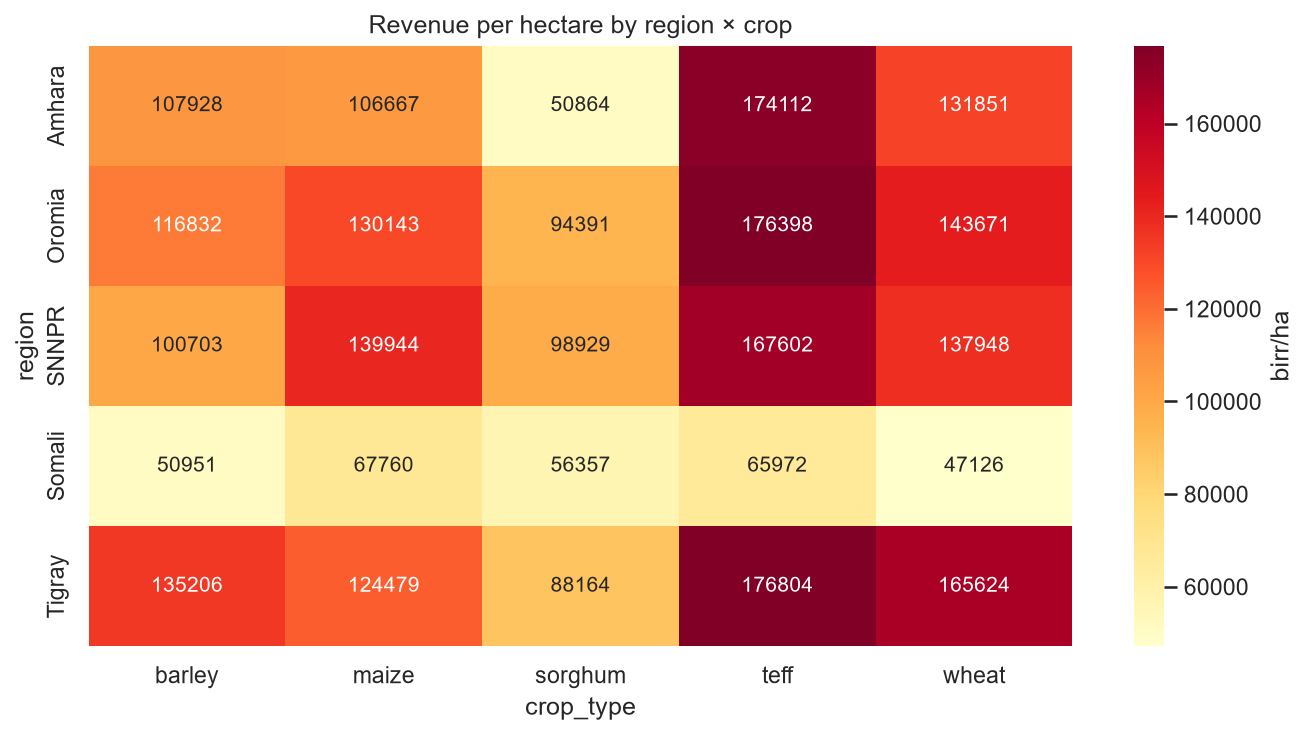

In [42]:
prices_clean = prices.copy()
price_avg = prices_clean.groupby(["region","crop_type"])["price_birr_per_quintal"].mean().reset_index()
yield_reg_crop = train.groupby(["region","crop_type"])["yield_tons_per_ha"].mean().reset_index()
rev = yield_reg_crop.merge(price_avg, on=["region","crop_type"], how="left")
rev["revenue"] = rev["yield_tons_per_ha"] * 10 * rev["price_birr_per_quintal"]
piv = rev.pivot(index="region", columns="crop_type", values="revenue")
plt.figure(figsize=(9, 5))
sns.heatmap(piv, annot=piv.round(0), fmt=".0f", cmap="YlOrRd", cbar_kws={"label":"birr/ha"})
plt.title("Revenue per hectare by region × crop")
plt.tight_layout(); plt.savefig(figdir/"fig09_revenue_by_crop_region.png", bbox_inches="tight"); plt.show()

Cell 11 — fig10 model comparison (load from a saved JSON; fill after Notebook 04) 

In [43]:
import json
path = PROJECT_ROOT / "reports" / "model_comparison.json"
if path.exists():
    data = json.loads(path.read_text())
    names = list(data.keys()); rmses = [data[n]["rmse"] for n in names]
    errs  = [data[n].get("rmse_std",0) for n in names]
    plt.figure(figsize=(10,5))
    bars = plt.bar(names, rmses, yerr=errs, color="steelblue", capsize=6)
    for b,v in zip(bars, rmses): plt.text(b.get_x()+b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom")
    plt.axhline(data.get("__baseline__", {}).get("rmse", np.nan), ls="--", color="red", label="mean baseline")
    plt.ylabel("Validation RMSE (t/ha)"); plt.title("Model comparison")
    plt.xticks(rotation=30); plt.legend()
    plt.tight_layout(); plt.savefig(figdir/"fig10_model_comparison.png", bbox_inches="tight"); plt.show()
else:
    print("Run Notebook 04 first; then re-run this cell.")

Run Notebook 04 first; then re-run this cell.


Cell 12 — fig11 predicted vs actual (fill after Notebook 04)

In [44]:
pred_path = PROJECT_ROOT / "reports" / "validation_preds.csv"
if pred_path.exists():
    vp = pd.read_csv(pred_path)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(vp["y_true"], vp["y_pred"], s=6, alpha=0.3)
    lims = [0, max(vp["y_true"].max(), vp["y_pred"].max())+0.5]
    axes[0].plot(lims, lims, "--", color="red"); axes[0].set_xlim(lims); axes[0].set_ylim(lims)
    axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted"); axes[0].set_title("Predicted vs actual")
    axes[1].scatter(vp["y_pred"], vp["y_true"]-vp["y_pred"], s=6, alpha=0.3)
    axes[1].axhline(0, color="red", ls="--")
    axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual"); axes[1].set_title("Residuals")
    plt.tight_layout(); plt.savefig(figdir/"fig11_predicted_vs_actual_residuals.png", bbox_inches="tight"); plt.show()
else:
    print("Run Notebook 04 first; then re-run this cell.")

Run Notebook 04 first; then re-run this cell.


Cell 13 — fig12 feature importance (fill after Notebook 04)

In [45]:
imp_path = PROJECT_ROOT / "reports" / "feature_importance.csv"
if imp_path.exists():
    imp = pd.read_csv(imp_path).sort_values("importance", ascending=False).head(15)
    colors = ["darkorange" if "season" in f or "temp" in f or "rain" in f or "heat" in f
              else "steelblue" for f in imp["feature"]]
    plt.figure(figsize=(9,6))
    plt.barh(imp["feature"][::-1], imp["importance"][::-1], color=colors[::-1])
    plt.xlabel("Permutation importance"); plt.title("Top features (weather-derived = orange)")
    plt.tight_layout(); plt.savefig(figdir/"fig12_feature_importance.png", bbox_inches="tight"); plt.show()
else:
    print("Run Notebook 04 first; then re-run this cell.")

Run Notebook 04 first; then re-run this cell.


Cell 14 — figure captions file

In [46]:
captions = """# Figure captions

- **fig01_missingness.png** — Share of missing values per column across train, test, and weather. Shows that fertilizer, soil quality, and labor days are the main missing columns.
- **fig02_before_after_cleaning.png** — Distribution of farm_size_ha before and after capping the 99th percentile. Cleaning removes the long impossible tail without discarding rows.
- **fig03_yield_distribution.png** — Yield (t/ha) overall and by crop. Maize dominates the mean; teff and barley are lower-yield and tighter.
- **fig04_region_crop_heatmap.png** — Mean yield by region × crop with plot counts. Some cells are thin and shouldn't be over-interpreted.
- **fig05_correlation_heatmap.png** — Correlations between numeric plot features, weather-derived features, and yield. Season temperature and altitude stand out.
- **fig06_climate_by_region.png** — Monthly average temperature by region, with the typical kiremt growing window shaded. Regions separate cleanly in temperature.
- **fig07_yield_vs_season_temp.png** — Yield vs season mean temperature per crop. Several crops show a sweet spot rather than a monotonic trend.
- **fig08_price_trends.png** — Average price per quintal by year and crop. Prices rose across the board, but unevenly.
- **fig09_revenue_by_crop_region.png** — Estimated revenue per hectare by region and crop. The ranking differs from yield alone because prices differ.
- **fig10_model_comparison.png** — Validation RMSE for each model family, with the mean baseline marked and CV error bars on the winner.
- **fig11_predicted_vs_actual_residuals.png** — Predicted vs actual and residuals. Residuals fan out at higher yield, which the error analysis discusses.
- **fig12_feature_importance.png** — Permutation importances for top features, with weather-derived features highlighted in orange.
"""
(figdir / "figure_captions.md").write_text(captions)
print("Wrote figure_captions.md")

Wrote figure_captions.md
